In [ ]:
!git clone https://github.com/Davida4200/data-xperience-trabajo-final.git
%cd data-xperience-trabajo-final

Cloning into 'data-xperience-trabajo-final'...
remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 22 (delta 5), reused 15 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (22/22), 104.45 KiB | 1.71 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/data-xperience-trabajo-final/data-xperience-trabajo-final/data-xperience-trabajo-final


In [ ]:
import pandas as pd

df = pd.read_csv("data/survey.csv")
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [ ]:
df["Gender"].unique()

array(['Female', 'M', 'Male', 'male', 'female', 'm', 'Male-ish', 'maile',
       'Trans-female', 'Cis Female', 'F', 'something kinda male?',
       'Cis Male', 'Woman', 'f', 'Mal', 'Male (CIS)', 'queer/she/they',
       'non-binary', 'Femake', 'woman', 'Make', 'Nah', 'All', 'Enby',
       'fluid', 'Genderqueer', 'Female ', 'Androgyne', 'Agender',
       'cis-female/femme', 'Guy (-ish) ^_^', 'male leaning androgynous',
       'Male ', 'Man', 'Trans woman', 'msle', 'Neuter', 'Female (trans)',
       'queer', 'Female (cis)', 'Mail', 'cis male', 'A little about you',
       'Malr', 'p', 'femail', 'Cis Man',
       'ostensibly male, unsure what that really means'], dtype=object)

In [ ]:
def clean_gender(gender):
  g = str(gender).strip().lower() # Convierte el Object en string, elimina espacios y tabulaciones al inicio, y transforma el texto en minuscula.
  male = {"m", "male", "man", "cis male", "male-ish", "maile", "mal", "make", "malr", "cis man", "msle"}
  female = {"f", "female", "woman", "cis female", "femake", "female ", "cis-female/femme", "femail"}

  if g in male:
    return "Hombre"
  elif g in female:
    return "Mujer"
  else:
    return "Otro/No binario"

In [ ]:
df["Gender_limpio"] = df["Gender"].apply(clean_gender)
df["Gender_limpio"].value_counts()

,count
Gender_limpio,
Hombre,989
Mujer,246
Otro/No binario,24


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
Timestamp,0
Age,0
Gender,0
Country,0
state,515
self_employed,18
family_history,0
treatment,0
work_interfere,264
no_employees,0


In [ ]:
df['Age'].describe()

,Age
count,1.259000e+03
mean,7.942815e+07
std,2.818299e+09
min,-1.726000e+03
25%,2.700000e+01
50%,3.100000e+01
75%,3.600000e+01
max,1.000000e+11


In [ ]:
df = df[(df["Age"] >= 15) & (df["Age"] <= 80)]
df["Age"].describe()

,Age
count,1251.000000
mean,32.076739
std,7.288272
min,18.000000
25%,27.000000
50%,31.000000
75%,36.000000
max,72.000000


In [ ]:
df["work_interfere"] = df["work_interfere"].fillna("No aplica")
df["work_interfere"].value_counts()

,count
work_interfere,
Sometimes,464
No aplica,262
Never,212
Rarely,173
Often,140


In [ ]:
pd.crosstab(df["family_history"], df["treatment"], normalize="index") * 100

treatment,No,Yes
family_history,,
No,64.566929,35.433071
Yes,25.971370,74.028630


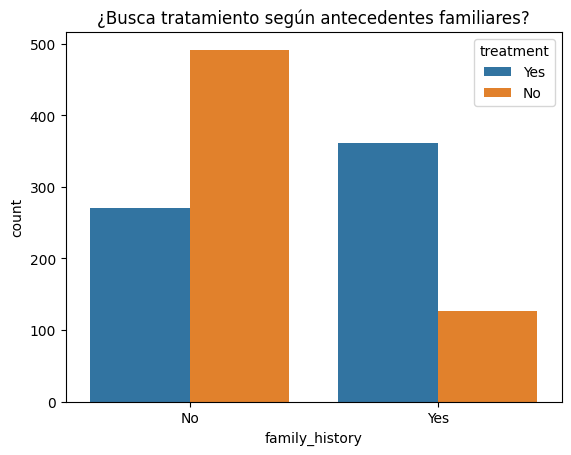

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="family_history", hue="treatment")
plt.title("¿Busca tratamiento según antecedentes familiares?")
plt.show()

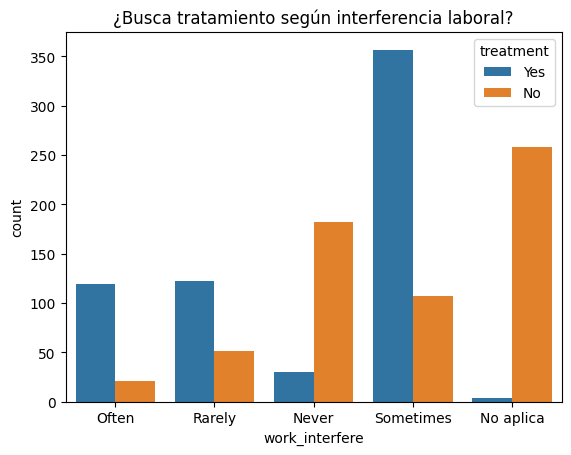

In [ ]:
sns.countplot(data=df, x="work_interfere", hue="treatment")
plt.title("¿Busca tratamiento según interferencia laboral?")
plt.show()

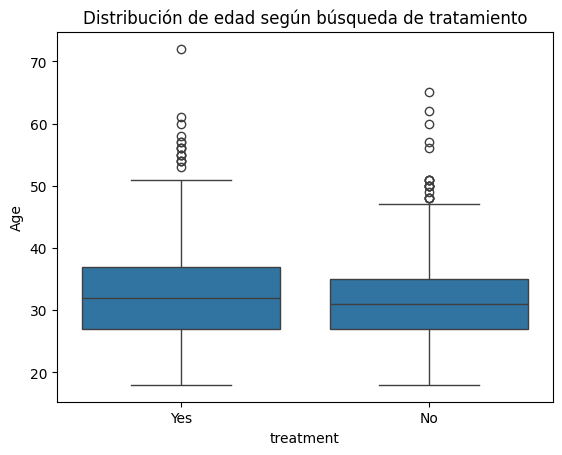

In [ ]:
sns.boxplot(data=df, x="treatment", y="Age")
plt.title("Distribución de edad según búsqueda de tratamiento")
plt.show()

In [ ]:
features_log = ["Age", "Gender_limpio", "family_history", "work_interfere",
                 "benefits", "care_options", "anonymity", "no_employees",
                 "remote_work", "tech_company"]

X = df[features_log]
y = df["treatment"]

In [ ]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,Age,Gender_limpio_Mujer,Gender_limpio_Otro/No binario,family_history_Yes,work_interfere_No aplica,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,benefits_No,benefits_Yes,...,care_options_Yes,anonymity_No,anonymity_Yes,no_employees_100-500,no_employees_26-100,no_employees_500-1000,no_employees_6-25,no_employees_More than 1000,remote_work_Yes,tech_company_Yes
0,37,True,False,False,False,True,False,False,False,True,...,False,False,True,False,False,False,True,False,False,True
1,44,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,32,False,False,False,False,False,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,31,False,False,True,False,True,False,False,True,False,...,True,True,False,False,True,False,False,False,False,True
4,31,False,False,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,True,True


In [ ]:
y = y.map({"Yes": 1, "No": 0})

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

y_pred = modelo_log.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.8434504792332268
Precision: 0.7945945945945946
Recall: 0.930379746835443


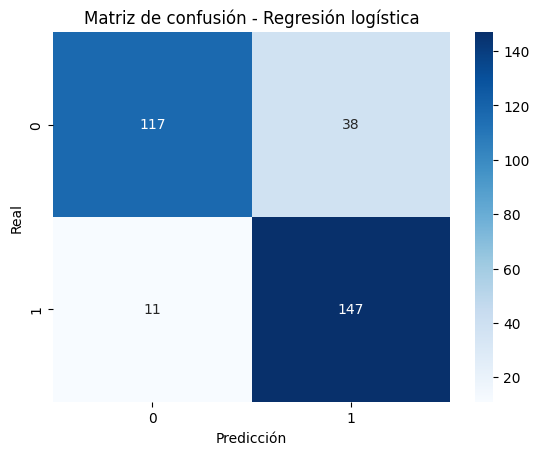

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Regresión logística")
plt.show()

In [ ]:
import numpy as np

odds = pd.Series(np.exp(modelo_log.coef_[0]), index=X.columns).sort_values(ascending=False)
odds

,0
work_interfere_Often,21.619403
work_interfere_Sometimes,11.880974
work_interfere_Rarely,7.299522
family_history_Yes,2.421966
Gender_limpio_Mujer,2.030565
no_employees_500-1000,1.813567
anonymity_Yes,1.725016
care_options_Yes,1.638066
no_employees_26-100,1.361226
benefits_Yes,1.268530
